# Final Project: Models

In [1]:
import pandas as pd
import numpy as np
from glob import glob
import re
import nltk
import plotly_express as px
from numpy.linalg import norm
import configparser

In [2]:
import seaborn as sns
import warnings
from scipy.linalg import norm
from scipy.linalg import eigh

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA

In [4]:
from gensim.models import word2vec
from gensim.corpora import Dictionary
from sklearn.manifold import TSNE as tsne

In [5]:
import gensim
gensim.__version__

'4.3.3'

In [6]:
pd.set_option('display.max_colwidth', None)

In [7]:
config = configparser.ConfigParser()
config.read("../../env.ini")
data_home = config['DEFAULT']['data_home']
output_dir = config['DEFAULT']['output_dir']
local_lib = config['DEFAULT']['local_lib']

In [8]:
data_prefix = 'dostoevsky'
source_files = f'{data_home}/gutenberg/dostoevsky-set'
colors = "YlGnBu"

In [9]:
OHCO = ['book_id', 'chap_id', 'para_num', 'sent_num', 'token_num']

In [10]:
import sys
sys.path.append(local_lib)

### Load Tables from Previous Sections:

In [11]:
LIB = pd.read_csv(f"{output_dir}/{data_prefix}-LIB.csv").set_index('book_id')
CORPUS = pd.read_csv(f"{output_dir}/{data_prefix}-CORPUS.csv").set_index(['book_id','chap_id','para_num','sent_num','token_num'])
VOCAB = pd.read_csv(f'{output_dir}/{data_prefix}-VOCAB.csv').set_index('term_str')
BOW = pd.read_csv(f'{output_dir}/{data_prefix}-BOW.csv').set_index(['book_id','chap_id','term_str'])
DTM = pd.read_csv(f'{output_dir}/{data_prefix}-DTM.csv').set_index(['book_id','chap_id'])
TFIDF = pd.read_csv(f'{output_dir}/{data_prefix}-TFIDF.csv').set_index(['book_id','chap_id'])
#L2 = pd.read_csv(f'{output_dir}/{data_prefix}-TFIDF_L2.csv').set_index(['book_id','chap_id'])

### PCA Components, Loadings, DCM

In [12]:
# Create DOC table for use in PCA function
DOC = pd.DataFrame(index=TFIDF.index)  
DOC = DOC.join(LIB[["type", "translator", "date", "title"]], on="book_id")
DOC["book_id"] = DOC.index.get_level_values("book_id")
DOC = DOC[[col for col in DOC.columns if col != "title"] + ["title"]]
DOC

type         translator  date  book_id  \
book_id chap_id                                              
600     1        novella  Constance Garnett  1864      600   
        2        novella  Constance Garnett  1864      600   
        3        novella  Constance Garnett  1864      600   
        4        novella  Constance Garnett  1864      600   
        5        novella  Constance Garnett  1864      600   
...                  ...                ...   ...      ...   
28054   92         novel  Constance Garnett  1880    28054   
        93         novel  Constance Garnett  1880    28054   
        94         novel  Constance Garnett  1880    28054   
        95         novel  Constance Garnett  1880    28054   
        96         novel  Constance Garnett  1880    28054   

                                      title  
book_id chap_id                              
600     1        NOTES FROM THE UNDERGROUND  
        2        NOTES FROM THE UNDERGROUND  
        3        NOTES FROM THE UNDERGROUND  
        4        NOTES FROM THE UNDERGROUND  
        5        NOTES FROM THE UNDERGROUND  
...                                     ...  
28054   92           THE BROTHERS KARAMAZOV  
        93           THE BROTHERS KARAMAZOV  
        94           THE BROTHERS KARAMAZOV  
        95           THE BROTHERS KARAMAZOV  
        96           THE BROTHERS KARAMAZOV  

[247 rows x 5 columns]

In [13]:
VOCAB_reduced = VOCAB[~VOCAB.max_pos.isin(['NNP'])].sort_values(by = 'dfidf', ascending = False).head(1000)
TFIDF_1000 = TFIDF[VOCAB_reduced.index]
# L2 TFIDF for PCA, without proper nouns
TFIDF_means = TFIDF_1000.groupby(['book_id', 'chap_id']).mean()
L2 = TFIDF_means.apply(lambda x: x / norm(x), 1) # Pythagorean, AKA Euclidean

In [14]:
# Dropping certain words because they are essentially used as proper nouns in Dostoevsky's work and were massively skewing results
L2 = L2.drop(columns=['prince', 'gentlemen', 'general'])

In [15]:
def get_PCA(X, k, norm_docs, center_by_mean, center_by_variance):
    
    # normalize if norm_docs is True
    if norm_docs == True:
        X = (X.T / norm(X, 2, axis=1)).T
    
    # drop na values
    X = X.dropna()
    
    # Centering by mean
    if center_by_mean:
        X = X - X.mean()
            
    # Centering by variance
    if center_by_variance: 
        X = X / X.var()
            
    #  get covariance matrix    
    COV = X.T.dot(X) / (X.shape[0] - 1)
    
    # decompose
    eig_vals, eig_vecs = eigh(COV)
    
    # convert eigen data to dataframes
    EIG_VEC = pd.DataFrame(eig_vecs, index=COV.index, columns=COV.index)
    EIG_VAL = pd.DataFrame(eig_vals, index=COV.index, columns=['eig_val'])
    EIG_VAL.index.name = 'term_str'
    
    # combine eigenvalues and eigenvectors
    EIG_PAIRS = EIG_VAL.join(EIG_VEC.T)
    
    # compute, pick top k components
    EIG_PAIRS['exp_var'] = np.round((EIG_PAIRS.eig_val / EIG_PAIRS.eig_val.sum()) * 100, 2)
    
    COMPS = EIG_PAIRS.sort_values('exp_var', ascending=False).head(k).reset_index(drop=True)
    COMPS.index.name = 'comp_id'
    COMPS.index = ["PC{}".format(i) for i in COMPS.index.tolist()]
    COMPS.index.name = 'pc_id'
    
    # Get Loadings
    LOADINGS = COMPS[COV.index].T
    LOADINGS.index.name = 'term_str'
    
    # Get DCM    
    DCM = X.dot(LOADINGS)
    DCM = DCM.join(DOC[["type", "translator", "date", "title"]], on=['book_id', 'chap_id'])
    
    # get COMPINF table -- I'm doing it like the COMPS and COMP_GLOSS table from the Lab notebook, 
    # not sure if that is what was meant by "the component information table" but it makes sense to me
    top_terms = []
    for i in range(10):
        for j in [0, 1]:
            comp_str = ' '.join(LOADINGS.sort_values(f'PC{i}', ascending=bool(j)).head(10).index.to_list())
            top_terms.append((f"PC{i}", j, comp_str))
    COMP_GLOSS = pd.DataFrame(top_terms).set_index([0,1]).unstack()
    COMP_GLOSS.index.name = 'comp_id'
    COMP_GLOSS.columns = COMP_GLOSS.columns.droplevel(0) 
    COMP_GLOSS = COMP_GLOSS.rename(columns={0:'pos', 1:'neg'})
    
    COMPINF = pd.DataFrame(COMPS['eig_val']).join(COMP_GLOSS, on ='pc_id')

    return LOADINGS, DCM, COMPINF

### PCA from Feature-Reduced TFIDF table

In [16]:
LOADINGS, DCM, COMPINF = get_PCA(L2, 10, True, False, False)
COMPINF

,eig_val,pos,neg
pc_id,,,
PC0,0.214079,finding failed flashing happens longed attentively intended setting helped fairly,ha letter thousand brother hes youre yesterday boy captain roubles
PC1,0.024862,events also replied family remarked play until wish wished marriage,hes murder murdered killed captain youre evidence brother kill blood
PC2,0.018329,sir ha captain boy crowd stairs water sofa street someone,evidence murder murdered thousand crime killed fathers speech letter facts
PC3,0.016164,faith children holy earth suffering child brother happy boy soul,thousand evidence notes sir hundred murder captain police length sum
PC4,0.014362,captain boy holy doctor crowd son visitors children peasants sir,ha marry letter tomorrow yesterday wish consciousness damn kill laughing
PC5,0.013666,stairs ha crowd consciousness murder crime garden someone murdered window,thousand captain hes youre boy marry brother hundred shes scoundrel
PC6,0.012364,thousand children around play faith holy earth notes crowd length,captain letter society doctor abroad police husband youre marriage sister
PC7,0.011769,doctor captain letter boy children child marry dreadful murdered murder,faith consciousness youre tea scoundrel nature damn thousand hundred glass
PC8,0.010975,garden husband married marriage girls letter wife women family peasant,captain doctor consciousness sir suffering faith nature play around stone


In [17]:
DCM

PC0       PC1       PC2       PC3       PC4       PC5  \
book_id chap_id                                                               
600     1       -0.251121  0.044317 -0.017767  0.034853  0.057715  0.011222   
        2       -0.208536  0.023887 -0.083174  0.116786 -0.128213  0.109131   
        3       -0.223436  0.024735 -0.061886  0.080305 -0.039398  0.126354   
        4       -0.190759  0.055763  0.057086  0.070360 -0.239169  0.205477   
        5       -0.212627  0.033660 -0.073606  0.152544 -0.090360  0.114934   
...                   ...       ...       ...       ...       ...       ...   
28054   92      -0.349262 -0.127084 -0.415915  0.050934  0.107851  0.145337   
        93      -0.361894 -0.123964 -0.286916 -0.000868  0.100930  0.112158   
        94      -0.297635 -0.070131 -0.143313  0.087726 -0.049377  0.002238   
        95      -0.436159 -0.174964 -0.051918  0.082714 -0.055910 -0.007307   
        96      -0.391708 -0.186861  0.150362  0.124090  0.164851 -0.115677   

                      PC6       PC7       PC8       PC9     type  \
book_id chap_id                                                    
600     1       -0.125798 -0.046670 -0.122570  0.031091  novella   
        2       -0.036535 -0.252414 -0.268182 -0.082753  novella   
        3       -0.015053 -0.213643 -0.229157 -0.117941  novella   
        4       -0.002900 -0.187631 -0.202818 -0.259966  novella   
        5        0.000826 -0.236008 -0.299204 -0.040117  novella   
...                   ...       ...       ...       ...      ...   
28054   92       0.149680  0.089430 -0.032626 -0.176486    novel   
        93       0.047397  0.037519 -0.026104 -0.131494    novel   
        94      -0.008152  0.048272 -0.065556  0.184469    novel   
        95       0.149941  0.121807 -0.128872  0.128370    novel   
        96       0.061294  0.181346 -0.127915 -0.199441    novel   

                        translator  date                       title  
book_id chap_id                                                       
600     1        Constance Garnett  1864  NOTES FROM THE UNDERGROUND  
        2        Constance Garnett  1864  NOTES FROM THE UNDERGROUND  
        3        Constance Garnett  1864  NOTES FROM THE UNDERGROUND  
        4        Constance Garnett  1864  NOTES FROM THE UNDERGROUND  
        5        Constance Garnett  1864  NOTES FROM THE UNDERGROUND  
...                            ...   ...                         ...  
28054   92       Constance Garnett  1880      THE BROTHERS KARAMAZOV  
        93       Constance Garnett  1880      THE BROTHERS KARAMAZOV  
        94       Constance Garnett  1880      THE BROTHERS KARAMAZOV  
        95       Constance Garnett  1880      THE BROTHERS KARAMAZOV  
        96       Constance Garnett  1880      THE BROTHERS KARAMAZOV  

[247 rows x 14 columns]

In [18]:
LOADINGS

pc_id,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
term_str,,,,,,,,,,
further,-0.028944,0.040413,0.000189,-0.033134,-0.003408,0.028164,0.016015,-0.009223,-0.014213,0.006059
frightened,-0.036873,-0.038622,0.026676,-0.002578,-0.028486,0.030260,0.000941,0.027399,0.011389,-0.006661
grew,-0.026858,0.033544,0.009009,0.003732,-0.001184,0.002624,-0.005136,0.012485,0.011098,-0.017912
forget,-0.027883,-0.017056,-0.005343,0.005687,-0.008331,-0.013849,0.020598,0.037225,-0.040278,0.007486
curiosity,-0.030989,0.021248,0.010507,-0.005087,-0.003062,0.013002,-0.010340,0.004687,-0.007715,0.019709
...,...,...,...,...,...,...,...,...,...,...
body,-0.026806,-0.017604,0.011941,0.007774,0.025505,0.067986,0.052480,0.000865,0.024422,0.041377
declare,-0.019972,0.018913,-0.007788,-0.007653,-0.025946,0.011800,-0.025844,-0.011458,-0.019006,-0.016527
charming,-0.023726,-0.001580,-0.011179,0.047973,0.004107,-0.026848,-0.018768,0.005510,-0.035745,0.012959


### PCA Visualizations 1 and 2

In [19]:
def vis_pcs(M, a, b, label, hover_name='title', symbol=None, size=None):
    return px.scatter(M, f"PC{a}", f"PC{b}", color=label, hover_name=hover_name, 
                     symbol=symbol, size=size,
                     marginal_x='box', height=800)

In [20]:
def vis_loadings(a=0, b=1, hover_name='term_str'):
    X = LOADINGS.join(VOCAB)
    return px.scatter(X.reset_index(), f"PC{a}", f"PC{b}", 
                      text='term_str', 
                      marginal_x='box', height=800)

/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/plotly/express/_core.py:2065: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sf: grouped.get_group(s if len(s) > 1 else s[0])


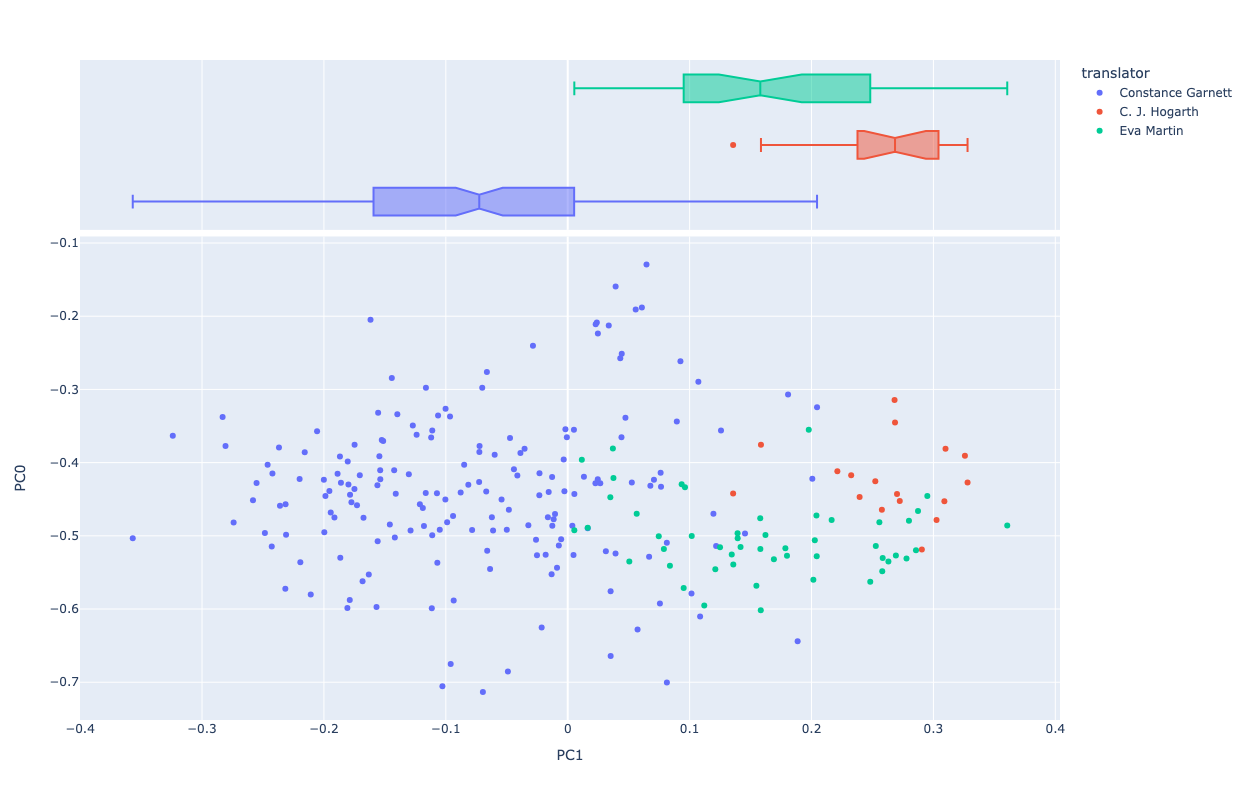

In [21]:
vis_pcs(DCM, 1, 0, label='translator')

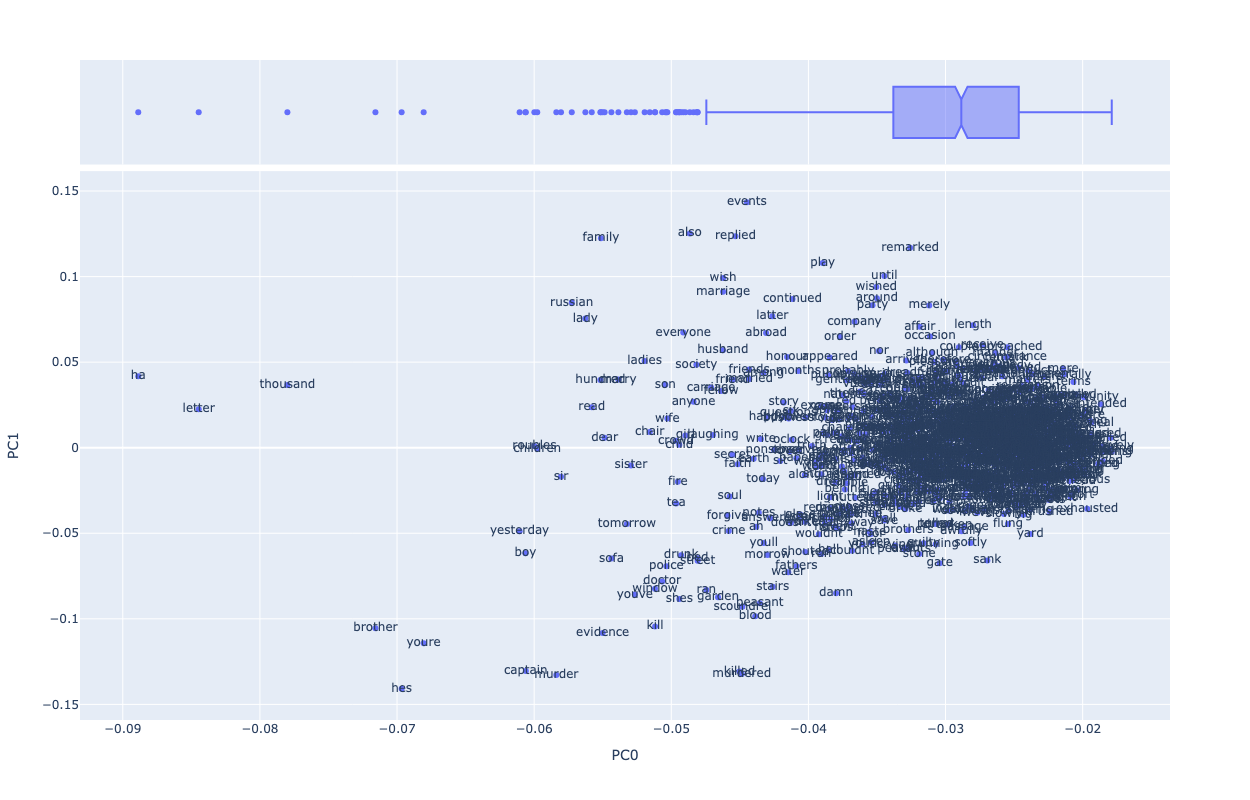

In [22]:
vis_loadings(0, 1)

/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



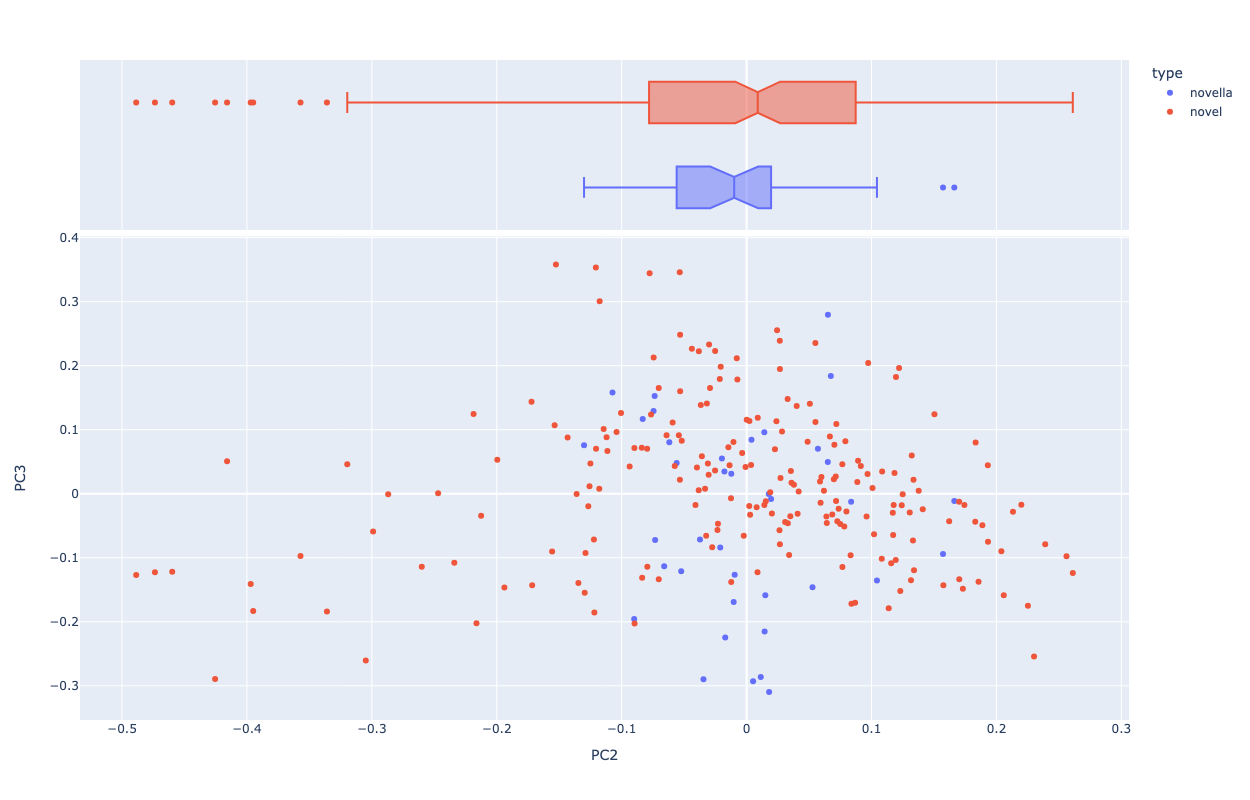

In [23]:
vis_pcs(DCM, 2, 3, label='type')

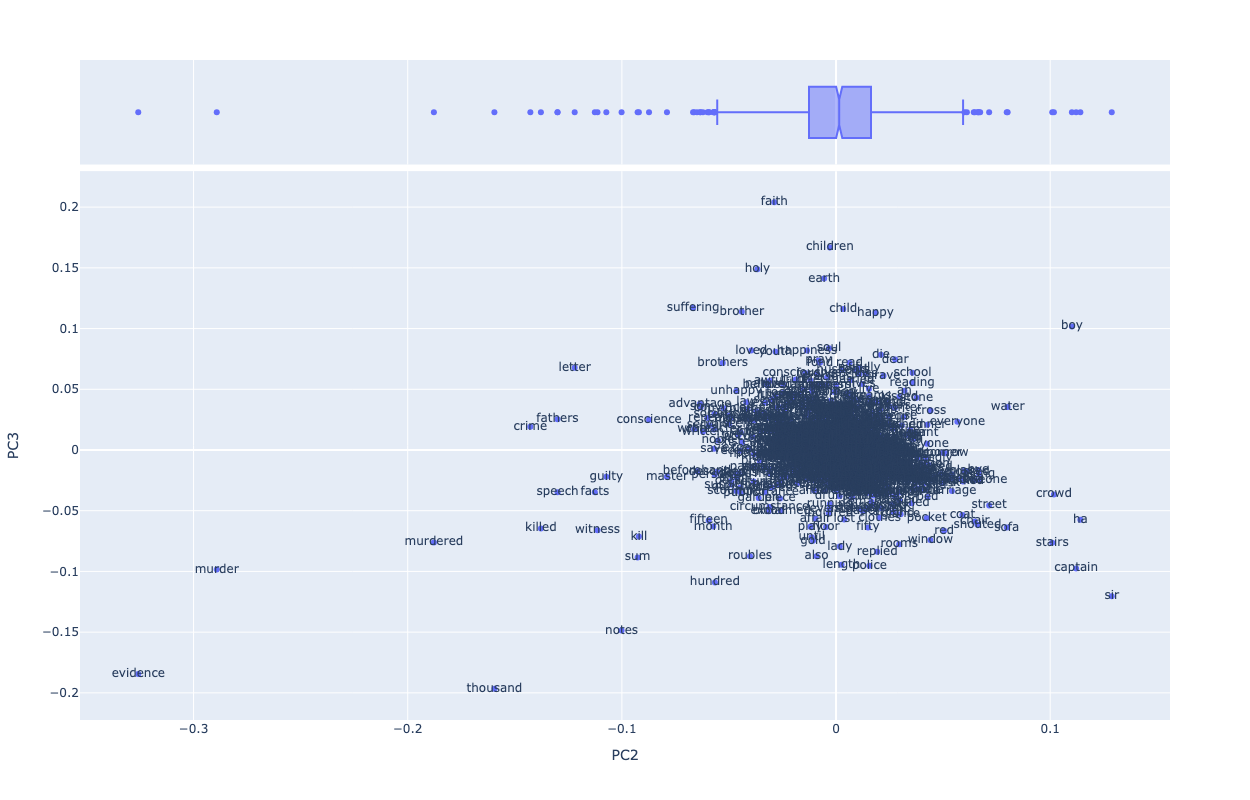

In [24]:
vis_loadings(2, 3)

### Setting up for LDA

In [113]:
ngram_range = (1, 2)
n_terms = 4000
n_topics = 20
max_iter = 5
n_top_terms = 5

In [114]:
OHCO = ['book_id', 'chap_id', 'para_num', 'sent_num', 'token_num']
PARA = OHCO[:3]
CHAP = OHCO[:2]
BOOK = OHCO[:1]

In [115]:
# get TOKENS as DOCS form to keep the existing naming conventions for this class
TOKENS = pd.read_csv(f'{output_dir}/{data_prefix}-CORPUS.csv').set_index(OHCO)

In [116]:
TOKENS.sample(10)

pos_tuple  pos token_str  \
book_id chap_id para_num sent_num token_num                                   
8117    6       74       3        4              ('a', 'DT')   DT         a   
28054   46      50       2        10          ('with', 'IN')   IN      with   
2554    37      34       1        11         ('after', 'IN')   IN     after   
2638    31      82       6        16            ('be', 'VB')   VB        be   
8117    2       114      0        3          ('now?"', 'RB')   RB     now?"   
2554    31      14       0        2            ('he', 'PRP')  PRP        he   
8117    11      178      0        53           ('on,', 'VB')   VB       on,   
2638    15      7        3        45            ('at', 'IN')   IN        at   
        19      16       0        2          ('took', 'VBD')  VBD      took   
8117    10      16       3        19            ('of', 'IN')   IN        of   

                                            term_str pos_group  
book_id chap_id para_num sent_num token_num                     
8117    6       74       3        4                a        DT  
28054   46      50       2        10            with        IN  
2554    37      34       1        11           after        IN  
2638    31      82       6        16              be        VB  
8117    2       114      0        3              now        RB  
2554    31      14       0        2               he        PR  
8117    11      178      0        53              on        VB  
2638    15      7        3        45              at        IN  
        19      16       0        2             took        VB  
8117    10      16       3        19              of        IN

In [117]:
BAG = PARA 

In [118]:
# this one removes "prince", and leaves only nouns but not propper nouns
DOCS = TOKENS[
    TOKENS.pos.str.match(r'^NNS?$') & (TOKENS.term_str != 'prince')
].groupby(BAG).term_str\
 .apply(lambda x: ' '.join(map(str,x)))\
 .to_frame()\
 .rename(columns={'term_str':'doc_str'})


In [119]:
DOCS

doc_str
book_id chap_id para_num                                                                                                                                                                          
600     1       1          man man man liver nothing disease me doctor it respect medicine doctors doctor spite though course case spite doctors them anyone else still doctor spite liver welllet
                2                                                               timetwenty years government service longer official rude pleasure so bribes recompense that least jest way purpose
                3                     petitioners information table teeth them enjoyment anybody part peopleof petitioners ones officer sword disgusting way feud months sword him it youth though
                4                          point spite point sting fact moment spleen shame man sparrows random it mouth doll cup tea sugar it teeth afterwards awake night shame months after way
                5         official spite petitioners officer reality moment myself elements me elements life outlet me them them out convulsions me me remorse something now forgiveness something
...                                                                                                                                                                                            ...
28054   96      73                                                                                                                                        rise joy gladness half half enthusiastic
                74                                                                                                                                                                           broke
                75                                                                                                                       dinner pancakesits custom theres something that hand hand
                76                                                                                                                         and lives hand hand rapturously boys exclamation hurrah
                77                                                                                                                                                                             end

[21238 rows x 1 columns]

In [120]:
count_engine = CountVectorizer(
    max_features= n_terms, ngram_range=ngram_range, stop_words='english')
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()

In [121]:
#VOCAB = pd.DataFrame(index=TERMS)
#VOCAB.index.name = 'term_str'

In [122]:
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)

In [123]:
#VOCAB['doc_count'] = DTM.astype('bool').astype('int').sum()
DOCS['term_count'] = DTM.sum(1)

In [124]:
#VOCAB

In [125]:
DOCS

doc_str  \
book_id chap_id para_num                                                                                                                                                                             
600     1       1          man man man liver nothing disease me doctor it respect medicine doctors doctor spite though course case spite doctors them anyone else still doctor spite liver welllet   
                2                                                               timetwenty years government service longer official rude pleasure so bribes recompense that least jest way purpose   
                3                     petitioners information table teeth them enjoyment anybody part peopleof petitioners ones officer sword disgusting way feud months sword him it youth though   
                4                          point spite point sting fact moment spleen shame man sparrows random it mouth doll cup tea sugar it teeth afterwards awake night shame months after way   
                5         official spite petitioners officer reality moment myself elements me elements life outlet me them them out convulsions me me remorse something now forgiveness something   
...                                                                                                                                                                                            ...   
28054   96      73                                                                                                                                        rise joy gladness half half enthusiastic   
                74                                                                                                                                                                           broke   
                75                                                                                                                       dinner pancakesits custom theres something that hand hand   
                76                                                                                                                         and lives hand hand rapturously boys exclamation hurrah   
                77                                                                                                                                                                             end   

                          term_count  
book_id chap_id para_num              
600     1       1                 18  
                2                 11  
                3                 12  
                4                 19  
                5                 11  
...                              ...  
28054   96      73                 6  
                74                 1  
                75                 6  
                76                 7  
                77                 1  

[21238 rows x 2 columns]

### Generate LDA Model

In [126]:
lda_engine = LDA(n_components=n_topics, 
                 max_iter=max_iter, 
                 learning_offset=50., 
                 random_state=0)

In [127]:
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

### LDA THETA

In [128]:
lda_model = lda_engine.fit_transform(count_model)

In [129]:
THETA = pd.DataFrame(lda_model, index=DOCS.index)
THETA.columns.name = 'topic_id'
THETA.columns = TNAMES

In [130]:
THETA.sample(10).T.style.background_gradient(cmap=colors, axis=None)

### LDA PHI

In [131]:
PHI = pd.DataFrame(lda_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'

In [132]:
PHI.T.sample(10).style.background_gradient(cmap=colors, axis=None)

topic_id,T00,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19
term_str,,,,,,,,,,,,,,,,,,,,
harmony,0.050000,0.050000,19.050671,0.050000,0.050000,0.050000,0.833155,0.050000,12.994641,0.052369,0.050000,2.469661,0.050000,2.610626,0.050000,0.050000,0.050000,2.338643,0.050236,0.050000
weapon,0.050000,0.050000,8.392215,0.050000,0.050000,0.050000,0.054168,3.334574,0.072115,0.050000,6.744481,3.136016,0.050000,0.050000,3.530926,2.135505,0.050000,0.050000,0.050000,0.050000
tear,0.050000,1.601751,0.050000,0.050000,0.050000,0.931401,0.050000,0.050000,5.050000,2.090265,0.050000,0.775974,0.050000,0.050000,0.050000,0.050000,5.703827,0.050000,2.196782,0.050000
head,9.596763,27.029391,22.230126,20.623379,25.183607,44.007607,14.032365,46.641472,27.600983,2.382112,4.428910,64.865753,61.633121,32.271097,96.884532,0.416984,10.290963,63.034587,7.731737,164.114511
paper pocket,0.050000,0.050000,0.050000,0.050000,0.050000,1.050000,2.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,4.050000,0.050000,0.050000,0.050000
daylight,0.050000,0.050000,0.050000,0.050000,7.664977,3.050000,0.050000,4.939928,0.050000,0.050000,0.050000,2.244656,0.050000,0.058935,0.050000,1.341503,0.050000,0.050000,0.050000,0.050000
sharply,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,1.195509,0.050000,0.050000,0.050000,2.572632,0.336771,7.959370,2.185717
struck,5.462279,2.087997,0.108214,1.084110,0.050000,0.050000,0.050000,0.057414,0.050078,2.254116,0.050000,2.001767,2.452467,0.344690,4.907802,0.050000,7.789066,0.050000,0.050000,0.050000
man money,0.050000,0.050000,0.050000,5.672503,1.347716,0.250865,0.050000,0.050000,4.009737,0.050000,0.050000,0.778533,0.050000,0.050000,3.240645,0.050001,0.050000,0.050000,0.050000,0.050000


### LDA TOPIC

In [133]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(
    x.sort_values(ascending=False).head(
        n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')

In [134]:
TOPICS.style

,top_terms
topic_id,
T00,love bye door silence surprise
T01,man way time course people
T02,oh people men man hands
T03,thats money place time question
T04,life years time woman man
T05,room time face hand hands
T06,letter brother word hand answer
T07,mind thought hour idea voice
T08,man business time people ah


## Sort Topics by Mean Doc Weight

In [135]:
TOPICS['doc_weight_mean'] = THETA.mean()
TOPICS.sort_values('doc_weight_mean', ascending=False).style.background_gradient(cmap=colors)

,top_terms,doc_weight_mean
topic_id,,
T11,yes eyes face smile man,0.067662
T16,room door table chair note,0.058986
T04,life years time woman man,0.054189
T06,letter brother word hand answer,0.053782
T02,oh people men man hands,0.051906
T19,right door thing head fool,0.051702
T03,thats money place time question,0.050825
T12,house way home day course,0.050825
T10,mother money roubles thousand sister,0.050611


**Best Guess Labels: fill this in later**

### LDA + PCA Visualization

### PCA from THETA table

In [49]:
THETA

T00       T01       T02       T03       T04  \
book_id chap_id para_num                                                     
600     1       1         0.002632  0.668542  0.002632  0.002632  0.002632   
                2         0.004167  0.611781  0.004167  0.004167  0.004167   
                3         0.003846  0.411651  0.003846  0.003846  0.003846   
                4         0.002500  0.002500  0.002500  0.002500  0.002500   
                5         0.004167  0.266552  0.658448  0.004167  0.004167   
...                            ...       ...       ...       ...       ...   
28054   96      73        0.007143  0.007143  0.403526  0.007143  0.007143   
                74        0.025000  0.025000  0.025000  0.025000  0.025000   
                75        0.007143  0.007143  0.007143  0.007143  0.007143   
                76        0.006250  0.006250  0.006250  0.006250  0.006250   
                77        0.025000  0.025000  0.025000  0.025000  0.025000   

                               T05       T06       T07       T08       T09  \
book_id chap_id para_num                                                     
600     1       1         0.002632  0.002632  0.002632  0.002632  0.002632   
                2         0.004167  0.004167  0.313219  0.004167  0.004167   
                3         0.319938  0.003846  0.003846  0.003846  0.003846   
                4         0.737313  0.002500  0.217687  0.002500  0.002500   
                5         0.004167  0.004167  0.004167  0.004167  0.004167   
...                            ...       ...       ...       ...       ...   
28054   96      73        0.007143  0.007143  0.007143  0.007143  0.007143   
                74        0.525000  0.025000  0.025000  0.025000  0.025000   
                75        0.007143  0.533877  0.007143  0.007143  0.007143   
                76        0.006250  0.881250  0.006250  0.006250  0.006250   
                77        0.025000  0.025000  0.025000  0.025000  0.025000   

                               T10       T11       T12       T13       T14  \
book_id chap_id para_num                                                     
600     1       1         0.002632  0.002632  0.002632  0.002632  0.002632   
                2         0.004167  0.004167  0.004167  0.004167  0.004167   
                3         0.003846  0.003846  0.003846  0.003846  0.203027   
                4         0.002500  0.002500  0.002500  0.002500  0.002500   
                5         0.004167  0.004167  0.004167  0.004167  0.004167   
...                            ...       ...       ...       ...       ...   
28054   96      73        0.467903  0.007143  0.007143  0.007143  0.007143   
                74        0.025000  0.025000  0.025000  0.025000  0.025000   
                75        0.007143  0.007143  0.007143  0.007143  0.007143   
                76        0.006250  0.006250  0.006250  0.006250  0.006250   
                77        0.025000  0.025000  0.025000  0.025000  0.025000   

                               T15       T16       T17       T18       T19  
book_id chap_id para_num                                                    
600     1       1         0.002632  0.002632  0.284089  0.002632  0.002632  
                2         0.004167  0.004167  0.004167  0.004167  0.004167  
                3         0.003846  0.003846  0.003846  0.003846  0.003846  
                4         0.002500  0.002500  0.002500  0.002500  0.002500  
                5         0.004167  0.004167  0.004167  0.004167  0.004167  
...                            ...       ...       ...       ...       ...  
28054   96      73        0.007143  0.007143  0.007143  0.007143  0.007143  
                74        0.025000  0.025000  0.025000  0.025000  0.025000  
                75        0.179615  0.165080  0.007143  0.007143  0.007143  
                76        0.006250  0.006250  0.006250  0.006250  0.006250  
                77        0.525000  0.025000  0.025000  0.0250

In [50]:
def get_PCA(X, k, norm_docs, center_by_mean, center_by_variance):
    
    # normalize if norm_docs is True
    if norm_docs == True:
        X = (X.T / norm(X, 2, axis=1)).T
    
    # drop na values
    X = X.dropna()
    
    # Centering by mean
    if center_by_mean:
        X = X - X.mean()
            
    # Centering by variance
    if center_by_variance: 
        X = X / X.var()
            
    #  get covariance matrix    
    COV = X.T.dot(X) / (X.shape[0] - 1)
    
    # decompose
    eig_vals, eig_vecs = eigh(COV)
    
    # convert eigen data to dataframes
    EIG_VEC = pd.DataFrame(eig_vecs, index=COV.index, columns=COV.index)
    EIG_VAL = pd.DataFrame(eig_vals, index=COV.index, columns=['eig_val'])
    EIG_VAL.index.name = 'term_str'
    
    # combine eigenvalues and eigenvectors
    EIG_PAIRS = EIG_VAL.join(EIG_VEC.T)
    
    # compute, pick top k components
    EIG_PAIRS['exp_var'] = np.round((EIG_PAIRS.eig_val / EIG_PAIRS.eig_val.sum()) * 100, 2)
    
    COMPS = EIG_PAIRS.sort_values('exp_var', ascending=False).head(k).reset_index(drop=True)
    COMPS.index.name = 'comp_id'
    COMPS.index = ["PC{}".format(i) for i in COMPS.index.tolist()]
    COMPS.index.name = 'pc_id'
    
    # Get Loadings
    LOADINGS = COMPS[COV.index].T
    LOADINGS.index.name = 'term_str'
    
    # Get DCM    
    DCM = X.dot(LOADINGS)
    #DCM = DCM.join(DOC[["type", "translator", "date", "title"]], on=['book_id', 'chap_id'])
    
    # get COMPINF table -- I'm doing it like the COMPS and COMP_GLOSS table from the Lab notebook, 
    # not sure if that is what was meant by "the component information table" but it makes sense to me
    #top_terms = []
    #for i in range(10):
    #    for j in [0, 1]:
    #        comp_str = ' '.join(LOADINGS.sort_values(f'PC{i}', ascending=bool(j)).head(10).index.to_list())
    #        top_terms.append((f"PC{i}", j, comp_str))
   # COMP_GLOSS = pd.DataFrame(top_terms).set_index([0,1]).unstack()
   # COMP_GLOSS.index.name = 'comp_id'
   # COMP_GLOSS.columns = COMP_GLOSS.columns.droplevel(0) 
  #  COMP_GLOSS = COMP_GLOSS.rename(columns={0:'pos', 1:'neg'})
    
  #  COMPINF = pd.DataFrame(COMPS['eig_val']).join(COMP_GLOSS, on ='pc_id')

    return LOADINGS, DCM#, COMPINF

In [51]:
theta_grouped = THETA.groupby('book_id').mean()
theta_grouped = theta_grouped.T

In [52]:
LOADINGS2, DCM2 = get_PCA(theta_grouped, 10, False, False, False)
DCM2

pc_id,PC0,PC1,PC2,PC3,PC4,PC5
T00,-0.110684,0.001041,0.000609,-0.010184,-0.002287,-0.000440
T01,-0.123043,-0.013546,-0.019458,0.009257,-0.004154,-0.011491
T02,-0.115255,-0.021417,0.019054,0.003796,0.005958,-0.000916
T03,-0.131852,0.045223,0.008840,0.003871,0.003960,-0.007663
T04,-0.133492,-0.006921,-0.015547,-0.006131,0.014389,0.004808
T05,-0.125710,-0.009268,-0.007425,0.001182,-0.011265,0.000061
T06,-0.120868,-0.004841,0.015743,-0.007481,0.006987,-0.005045
T07,-0.125715,0.013901,-0.004692,0.001543,-0.002722,0.001912
T08,-0.103400,0.002633,0.002455,-0.003438,-0.000363,0.000455
T09,-0.106945,-0.015226,0.005529,0.000227,0.001589,-0.004373


In [53]:
DCM2["topic_id"] = DCM2.index

In [54]:
DCM2 = DCM2.join(TOPICS[["doc_weight_mean"]], on=['topic_id'])
DCM2

,PC0,PC1,PC2,PC3,PC4,PC5,topic_id,doc_weight_mean
T00,-0.110684,0.001041,0.000609,-0.010184,-0.002287,-0.000440,T00,0.046327
T01,-0.123043,-0.013546,-0.019458,0.009257,-0.004154,-0.011491,T01,0.046938
T02,-0.115255,-0.021417,0.019054,0.003796,0.005958,-0.000916,T02,0.051906
T03,-0.131852,0.045223,0.008840,0.003871,0.003960,-0.007663,T03,0.050825
T04,-0.133492,-0.006921,-0.015547,-0.006131,0.014389,0.004808,T04,0.054189
T05,-0.125710,-0.009268,-0.007425,0.001182,-0.011265,0.000061,T05,0.049988
T06,-0.120868,-0.004841,0.015743,-0.007481,0.006987,-0.005045,T06,0.053782
T07,-0.125715,0.013901,-0.004692,0.001543,-0.002722,0.001912,T07,0.048754
T08,-0.103400,0.002633,0.002455,-0.003438,-0.000363,0.000455,T08,0.042710
T09,-0.106945,-0.015226,0.005529,0.000227,0.001589,-0.004373,T09,0.046026


In [55]:
def vis_pcs(M, a, b, label=None, hover_name=None, symbol=None, size='doc_weight_mean'):
    M['size_scaled'] = np.power(M[size], 4)  # Raise to power of 4 to make it easier to see (bigger difference between large and small points)
    plot = px.scatter(M, f"PC{a}", f"PC{b}", color=None, hover_name='topic_id', 
                     symbol=symbol, size='size_scaled',  # Use the transformed size column
                     marginal_x='box', height=800)
    return plot


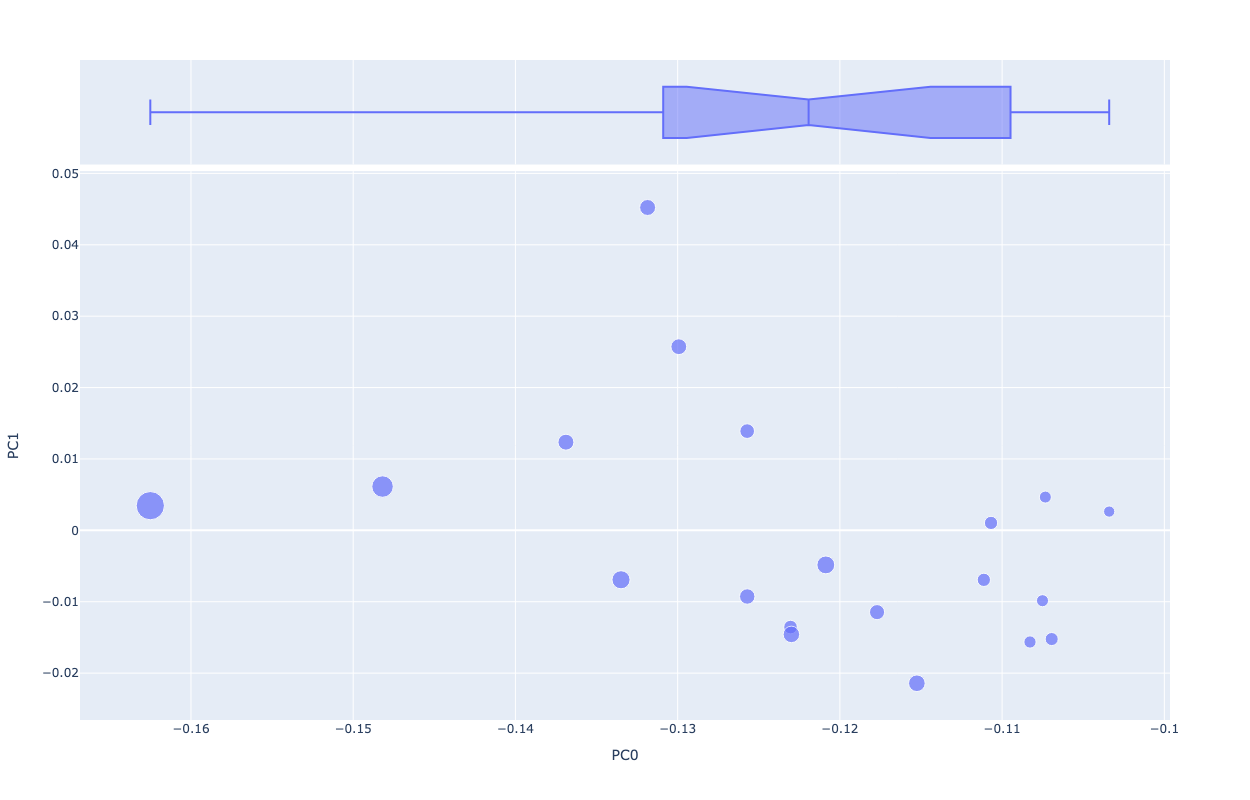

In [56]:
vis_pcs(DCM2, 0, 1, size='doc_weight_mean')

In [57]:
LOADINGS3, DCM3 = get_PCA(theta_grouped.T, 10, False, False, False)
DCM3

pc_id,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
book_id,,,,,,,,,,
600,-0.224437,0.026344,0.028227,-0.017280,-0.001363,0.000940,-1.688453e-16,-2.837466e-17,-5.204587e-18,6.579844e-17
2197,-0.228037,-0.061736,0.003294,-0.006390,0.000485,0.000340,-2.197606e-17,-5.217880e-17,1.270100e-17,-7.473357e-18
2554,-0.225428,0.006538,-0.005797,0.009322,-0.021676,0.004779,3.152830e-17,5.621197e-17,-3.275760e-17,-1.001992e-16
2638,-0.225600,0.006529,0.009760,0.016543,0.013624,0.010422,1.591569e-16,-1.847016e-17,2.171570e-17,-6.445008e-17
8117,-0.224849,0.007582,0.000227,0.008778,0.002810,-0.019208,-1.334434e-16,5.515729e-17,2.557831e-17,4.689842e-17
28054,-0.222949,0.015761,-0.036027,-0.011086,0.006173,0.002701,5.230180e-17,-2.647234e-18,1.374789e-17,-3.643384e-17


In [58]:
DCM3 = DCM3.join(LIB[["title","translator","date","type"]], on=['book_id'])
DCM3

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,title,translator,date,type
book_id,,,,,,,,,,,,,,
600,-0.224437,0.026344,0.028227,-0.017280,-0.001363,0.000940,-1.688453e-16,-2.837466e-17,-5.204587e-18,6.579844e-17,NOTES FROM THE UNDERGROUND,Constance Garnett,1864,novella
2197,-0.228037,-0.061736,0.003294,-0.006390,0.000485,0.000340,-2.197606e-17,-5.217880e-17,1.270100e-17,-7.473357e-18,THE GAMBLER,C. J. Hogarth,1866,novella
2554,-0.225428,0.006538,-0.005797,0.009322,-0.021676,0.004779,3.152830e-17,5.621197e-17,-3.275760e-17,-1.001992e-16,CRIME AND PUNISHMENT,Constance Garnett,1866,novel
2638,-0.225600,0.006529,0.009760,0.016543,0.013624,0.010422,1.591569e-16,-1.847016e-17,2.171570e-17,-6.445008e-17,THE IDIOT,Eva Martin,1869,novel
8117,-0.224849,0.007582,0.000227,0.008778,0.002810,-0.019208,-1.334434e-16,5.515729e-17,2.557831e-17,4.689842e-17,THE POSSESSED,Constance Garnett,1872,novel
28054,-0.222949,0.015761,-0.036027,-0.011086,0.006173,0.002701,5.230180e-17,-2.647234e-18,1.374789e-17,-3.643384e-17,THE BROTHERS KARAMAZOV,Constance Garnett,1880,novel


In [59]:
def vis_pcs(M, a, b, label=None, hover_name=None, symbol=None, size=None):
    plot = px.scatter(
        M, f"PC{a}", f"PC{b}", color='type', hover_name='title', 
        symbol=symbol, size=size,
        marginal_x='box', height=800
    )
    plot.update_traces(marker=dict(size=20))  # making points bigger for better visibility
    return plot


/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



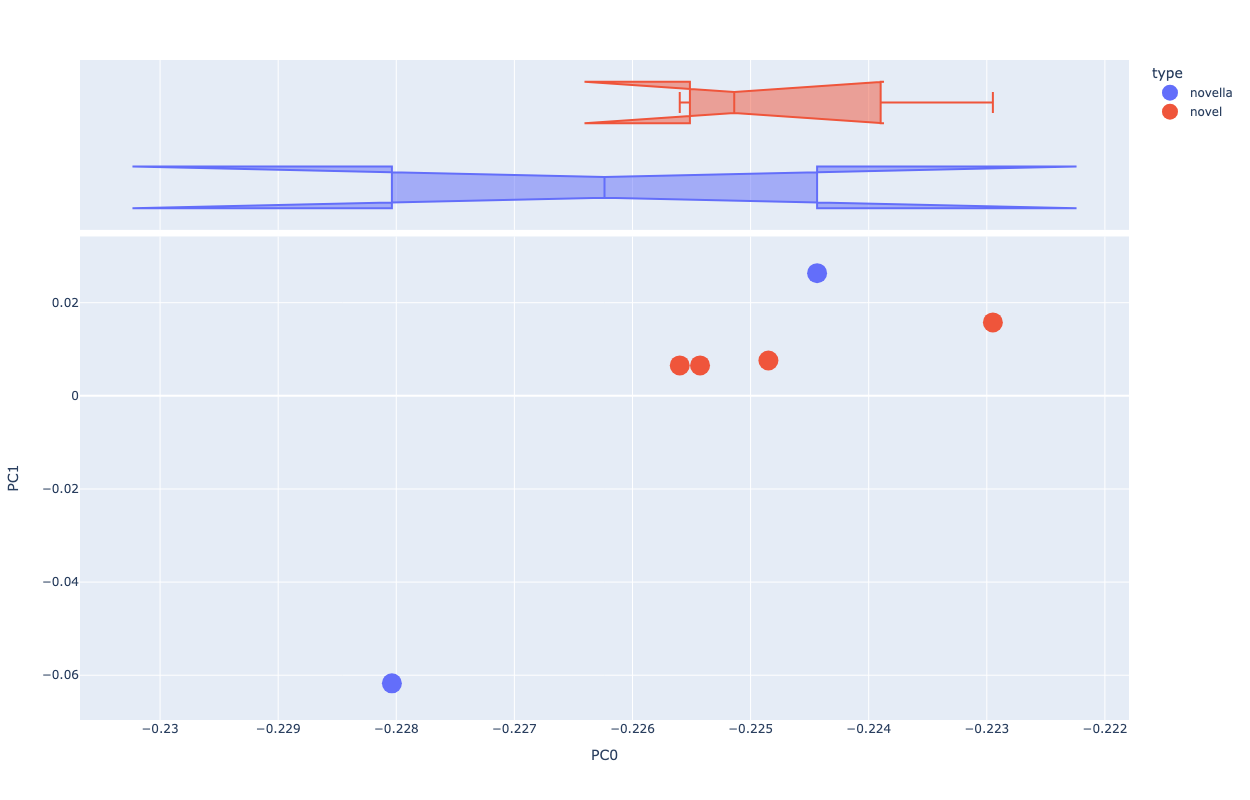

In [60]:
vis_pcs(DCM3, 0, 1)

### Sentiment VOCAB_SENT, BOW_SENT, DOC_SENT

In [61]:
salex_csv = f'{data_home}/lexicons/salex_nrc.csv'
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()

In [62]:
SALEX = pd.read_csv(salex_csv).set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]

In [63]:
SALEX

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
young,0,1,0,0,1,0,1,0,1,0,1
youth,1,1,0,1,1,0,1,0,1,0,1
zeal,0,1,0,0,1,0,1,0,1,1,1


In [64]:
VOCAB = pd.read_csv(f'{output_dir}/{data_prefix}-VOCAB.csv').set_index('term_str')

In [65]:
VOCAB_SENT = pd.concat([VOCAB.reset_index().set_index('term_str'), SALEX], join='inner', axis=1)

In [66]:
VOCAB_SENT.sample(10)

,n,n_chars,p,i,max_pos,max_pos_group,stop,porter_stem,dfidf,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,,,,,,,,,,
revolver,66,8,5.713440e-05,14.095281,NN,NN,0,revolv,43.005980,1,0,0,1,0,1,0,1,0,0,-1
abundance,2,9,1.731345e-06,19.139675,NN,NN,0,abund,13.896734,0,1,1,0,1,1,1,0,0,1,0
prison,106,6,9.176131e-05,13.411755,NN,NN,0,prison,108.450407,1,0,0,1,0,1,0,1,0,0,-1
speck,2,5,1.731345e-06,19.139675,NN,NN,0,speck,13.896734,0,0,1,0,0,1,0,0,0,0,-1
reputable,1,9,8.656727e-07,20.139675,JJ,JJ,0,reput,7.948367,0,0,0,0,0,0,1,0,0,1,1
sly,56,3,4.847767e-05,14.332320,NN,NN,0,sli,105.057565,1,0,1,1,0,1,0,0,0,0,-1
pervert,1,7,8.656727e-07,20.139675,NN,NN,0,pervert,7.948367,1,0,1,0,0,1,0,0,0,0,-1
withdraw,13,8,1.125375e-05,16.439235,VB,VB,0,withdraw,55.223058,0,0,0,0,0,1,0,1,0,0,-1
denied,11,6,9.522400e-06,16.680243,VBN,VB,0,deni,43.005980,0,0,0,0,0,1,0,1,0,0,-1


In [67]:
BOW_SENT = BOW.join(VOCAB_SENT[['max_pos'] + emo_cols], on='term_str', rsuffix='_v').dropna()
BOW_SENT

n     tfidf       dfidf max_pos  anger  \
book_id chap_id term_str                                            
600     1       amuse      1  0.001871   78.770521      VB    0.0   
                amusing    2  0.002774   94.347751     VBG    0.0   
                ashamed    1  0.006021  128.370827     VBN    0.0   
                bad        3  0.004925  130.451104      JJ    1.0   
                case       1  0.006357  104.197638      NN    0.0   
...                       ..       ...         ...     ...    ...   
28054   96      white      3  0.004373  130.698424      JJ    0.0   
                wholesome  1  0.000241   13.896734      JJ    0.0   
                wicked     1  0.002630   91.244299      JJ    0.0   
                word       3  0.003446   46.734717      NN    0.0   
                words      2  0.005063   72.977589     NNS    1.0   

                           anticipation  disgust  fear  joy  sadness  \
book_id chap_id term_str                                               
600     1       amuse               0.0      0.0   0.0  1.0      0.0   
                amusing             0.0      0.0   0.0  1.0      0.0   
                ashamed             0.0      1.0   0.0  0.0      1.0   
                bad                 0.0      1.0   1.0  0.0      1.0   
                case                0.0      0.0   1.0  0.0      1.0   
...                                 ...      ...   ...  ...      ...   
28054   96      white               1.0      0.0   0.0  1.0      0.0   
                wholesome           0.0      0.0   0.0  0.0      0.0   
                wicked              0.0      0.0   1.0  0.0      0.0   
                word                0.0      0.0   0.0  0.0      0.0   
                words               0.0      0.0   0.0  0.0      0.0   

                           surprise  trust  sentiment  
book_id chap_id term_str                               
600     1       amuse           0.0    0.0        1.0  
                amusing         0.0    0.0        1.0  
                ashamed         0.0    0.0       -1.0  
                bad             0.0    0.0       -1.0  
                case            0.0    0.0       -1.0  
...                             ...    ...        ...  
28054   96      white           0.0    1.0        1.0  
                wholesome       0.0    1.0        1.0  
                wicked          0.0    0.0       -1.0  
                word            0.0    1.0        1.0  
                words           0.0    0.0       -1.0  

[42168 rows x 13 columns]

In [68]:
DOC_SENT = BOW_SENT.groupby(['book_id','chap_id'])[emo_cols].mean()
DOC_SENT

anger  anticipation   disgust      fear       joy  \
book_id chap_id                                                         
600     1        0.366667      0.133333  0.433333  0.366667  0.233333   
        2        0.433333      0.200000  0.400000  0.333333  0.200000   
        3        0.394737      0.118421  0.263158  0.342105  0.210526   
        4        0.255814      0.325581  0.279070  0.465116  0.325581   
        5        0.409091      0.136364  0.318182  0.318182  0.181818   
...                   ...           ...       ...       ...       ...   
28054   92       0.363636      0.250000  0.232955  0.431818  0.267045   
        93       0.283582      0.283582  0.194030  0.298507  0.246269   
        94       0.338983      0.177966  0.254237  0.398305  0.177966   
        95       0.328767      0.226027  0.246575  0.431507  0.232877   
        96       0.290541      0.209459  0.222973  0.364865  0.310811   

                  sadness  surprise     trust  sentiment  
book_id chap_id                                           
600     1        0.383333  0.083333  0.283333  -0.283333  
        2        0.366667  0.150000  0.300000  -0.316667  
        3        0.315789  0.105263  0.315789  -0.250000  
        4        0.348837  0.186047  0.186047  -0.255814  
        5        0.363636  0.045455  0.363636  -0.340909  
...                   ...       ...       ...        ...  
28054   92       0.323864  0.176136  0.312500  -0.170455  
        93       0.276119  0.171642  0.350746  -0.044776  
        94       0.406780  0.118644  0.279661  -0.288136  
        95       0.369863  0.143836  0.342466  -0.239726  
        96       0.425676  0.155405  0.317568  -0.168919  

[247 rows x 9 columns]

### Sentiment Plot

In [69]:
# Adding year into DOC_SENT to plot over time

BOW_SENT2 = BOW_SENT.join(LIB['date'], on = 'book_id')
DOC_SENT2 = BOW_SENT2.groupby('date')[emo_cols].mean()
DOC_SENT2

#DCM = DCM.join(DOC[["type", "translator", "date", "title"]], on=['book_id', 'chap_id'])


,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
date,,,,,,,,,
1864,0.324225,0.229637,0.266947,0.343142,0.272202,0.332107,0.146611,0.306884,-0.172885
1866,0.292311,0.253497,0.225834,0.342590,0.258441,0.329231,0.164300,0.311560,-0.159882
1869,0.277449,0.261923,0.208198,0.305596,0.294426,0.308165,0.171228,0.334301,-0.061544
1872,0.303806,0.245144,0.218373,0.346325,0.266142,0.313780,0.163386,0.315486,-0.135564
1880,0.303983,0.253366,0.230384,0.350300,0.274727,0.324427,0.163060,0.324780,-0.119140


In [70]:
SENT_BY_DATE = DOC_SENT2.stack().to_frame().reset_index().rename(columns={0:'value','level_1':'emotion'})

In [71]:
def plot_sentiments(df, emo='sentiment'):
    FIG = dict(figsize=(25, 5), legend=True, fontsize=14, rot=45)
    df[emo].plot(**FIG)

/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



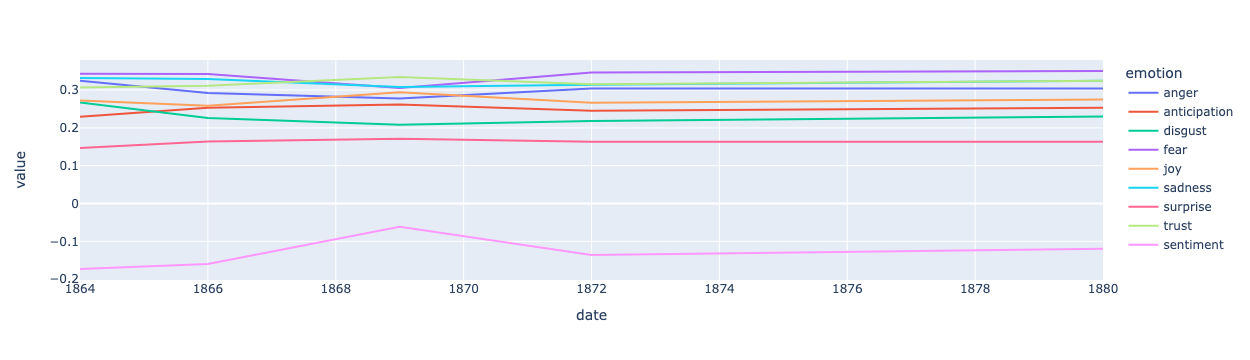

In [72]:
px.line(SENT_BY_DATE, x='date', y='value', color='emotion')

### VOCAB_W2V

In [73]:
# word2vec parameters
w2v_params = dict(
    window = 5,
    vector_size = 246,
    min_count = 50,
    workers = 4
)

In [74]:
# TOKENS

In [75]:
docs = TOKENS[~TOKENS.pos.str.match('NNPS?')].dropna(subset=['term_str'])\
    .groupby(BAG)\
    .term_str.apply(lambda  x:  x.tolist())\
    .reset_index()['term_str'].tolist()
docs = [doc for doc in docs if len(doc) > 1] # Lose single word docs

In [76]:
print(docs[:2])

[['i', 'am', 'a', 'sick', 'man', 'i', 'am', 'a', 'spiteful', 'man', 'i', 'am', 'an', 'unattractive', 'man', 'i', 'believe', 'my', 'liver', 'is', 'diseased', 'i', 'know', 'nothing', 'at', 'all', 'about', 'my', 'disease', 'and', 'do', 'not', 'know', 'for', 'certain', 'what', 'ails', 'me', 'i', 'dont', 'consult', 'a', 'doctor', 'for', 'it', 'and', 'never', 'have', 'though', 'i', 'have', 'a', 'respect', 'for', 'medicine', 'and', 'doctors', 'i', 'am', 'extremely', 'superstitious', 'sufficiently', 'so', 'to', 'respect', 'medicine', 'anyway', 'am', 'well', 'educated', 'enough', 'not', 'to', 'be', 'superstitious', 'but', 'i', 'am', 'superstitious', 'i', 'refuse', 'to', 'consult', 'a', 'doctor', 'from', 'spite', 'that', 'you', 'probably', 'will', 'not', 'understand', 'i', 'understand', 'it', 'though', 'of', 'course', 'i', 'cant', 'explain', 'who', 'it', 'is', 'precisely', 'that', 'i', 'am', 'mortifying', 'in', 'this', 'case', 'by', 'my', 'spite', 'i', 'am', 'perfectly', 'well', 'aware', 'that',

In [77]:
vocab = Dictionary(docs)

# Generate word embeddings with Gensim's module

In [78]:
model = word2vec.Word2Vec(docs, **w2v_params)

In [79]:
model.wv.vectors

array([[-0.56800497, -0.6070258 ,  0.23743199, ...,  0.55084395,
        -0.36635843,  0.19092765],
       [-0.44121504, -0.5693041 , -0.25794712, ..., -0.24888259,
         0.29747114,  0.2218933 ],
       [ 0.0521256 ,  0.32454306, -0.3665675 , ..., -0.69397783,
        -0.94685155,  0.22972111],
       ...,
       [-0.18174154, -0.10980595,  0.0992412 , ..., -0.03961612,
         0.11443172,  0.02144315],
       [-0.02321151, -0.141966  , -0.01880943, ..., -0.03829558,
         0.10325676,  0.1724709 ],
       [ 0.05944688, -0.07854958,  0.00935179, ...,  0.13036154,
        -0.06677568,  0.02897091]], dtype=float32)

# Visualize with tSNE

## Convert model to data frame

In [80]:
def get_vector(row):
    w = row.name
    try:
        vec = model.wv[w]
    except KeyError as e:
        vec = None
    return vec

In [139]:
VOCAB_W2V = pd.DataFrame(VOCAB.apply(get_vector, axis=1).dropna()).apply(lambda x: pd.Series(x[0]), axis=1)

In [140]:
VOCAB_W2V

,0,1,2,3,4,5,6,7,8,9,...,236,237,238,239,240,241,242,243,244,245
term_str,,,,,,,,,,,,,,,,,,,,,
a,0.418391,-0.103677,-0.488514,-0.344636,0.196380,0.374183,-0.790330,0.756046,0.395441,0.510596,...,-0.127964,-0.050688,0.327409,1.109599,0.208374,0.839711,-0.502092,0.357162,0.391345,0.405797
able,-0.188197,0.088054,-0.350938,-0.242123,-0.091906,0.536320,0.354705,0.259318,0.469651,0.256162,...,0.523522,-0.193125,0.002158,-0.249835,-0.139723,-0.217233,-0.287058,0.117132,-0.323409,0.170799
about,0.099110,0.350876,-0.117422,-0.224732,-0.126208,-0.541211,-0.561907,-0.168894,-0.501538,0.007591,...,0.604861,0.451115,-0.216462,-0.379818,0.521719,-0.480361,0.547854,-0.324327,0.222317,-0.085353
above,-0.022943,-0.095214,0.220393,-0.112079,-0.058406,0.062461,-0.029079,0.001260,-0.277812,0.210747,...,0.042585,0.077879,0.144983,-0.233912,-0.131107,0.252381,-0.006379,-0.099003,-0.295663,-0.093683
abroad,-0.141158,-0.064810,-0.167618,-0.015882,-0.114359,0.169243,-0.227901,-0.205750,-0.169707,-0.222319,...,0.026359,-0.149421,-0.156151,0.039034,0.014232,-0.356702,0.118096,0.142464,-0.088802,-0.126938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
youre,0.312440,-0.186297,0.020518,0.193925,0.030020,-0.756145,-0.004316,-0.114353,0.712439,0.393236,...,0.038435,0.011603,-0.139318,-0.036807,0.017468,0.061861,0.101582,0.222337,0.000995,-0.044497
yours,0.056808,-0.053548,0.180622,-0.336439,-0.124401,-0.134217,-0.254668,-0.488928,0.189955,0.246921,...,0.236818,-0.059117,0.064537,0.019099,0.083683,0.002315,0.001674,-0.047439,-0.107684,-0.110766
yourself,-0.245681,0.148922,0.053801,0.173739,-0.324897,-0.497331,0.151856,0.041171,0.772718,0.381543,...,0.030991,0.087273,0.057948,-0.121326,0.113191,-0.667516,-0.082446,0.130674,0.104946,-0.066722


In [83]:
tsne_engine = tsne(learning_rate = 200, perplexity=20, n_components=2, init='random', n_iter=1000, random_state=97)

In [84]:
tsne_model = tsne_engine.fit_transform(VOCAB_W2V.to_numpy())

In [85]:
TSNE = pd.DataFrame(tsne_model, columns=['x','y'], index=VOCAB_W2V.index)

In [86]:
TSNE

,x,y
term_str,,
a,-29.538818,-16.962280
able,49.606995,-27.077959
about,34.212231,-31.800522
above,-1.243099,-15.885977
abroad,-10.469568,-8.084970
...,...,...
youre,36.250938,-23.119930
yours,28.730679,-23.321430
yourself,53.844238,-12.404390


### Plot the coordinates

In [87]:
X = TSNE.join(VOCAB, how='left')

In [88]:
X['n_log'] = np.log(X.n)

In [89]:
X.head()

,x,y,n,n_chars,p,i,max_pos,max_pos_group,stop,porter_stem,dfidf,n_log
term_str,,,,,,,,,,,,
a,-29.538818,-16.962280,24091,1,0.020855,5.583468,DT,DT,1,a,0.000000,10.089594
able,49.606995,-27.077959,217,4,0.000188,12.378124,JJ,JJ,0,abl,119.857694,5.379897
about,34.212231,-31.800522,2921,5,0.002529,8.627428,IN,IN,1,about,5.723799,7.979681
above,-1.243099,-15.885977,197,5,0.000171,12.517623,IN,IN,1,abov,126.126294,5.283204
abroad,-10.469568,-8.084970,156,6,0.000135,12.854273,RB,RB,0,abroad,118.447905,5.049856


/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



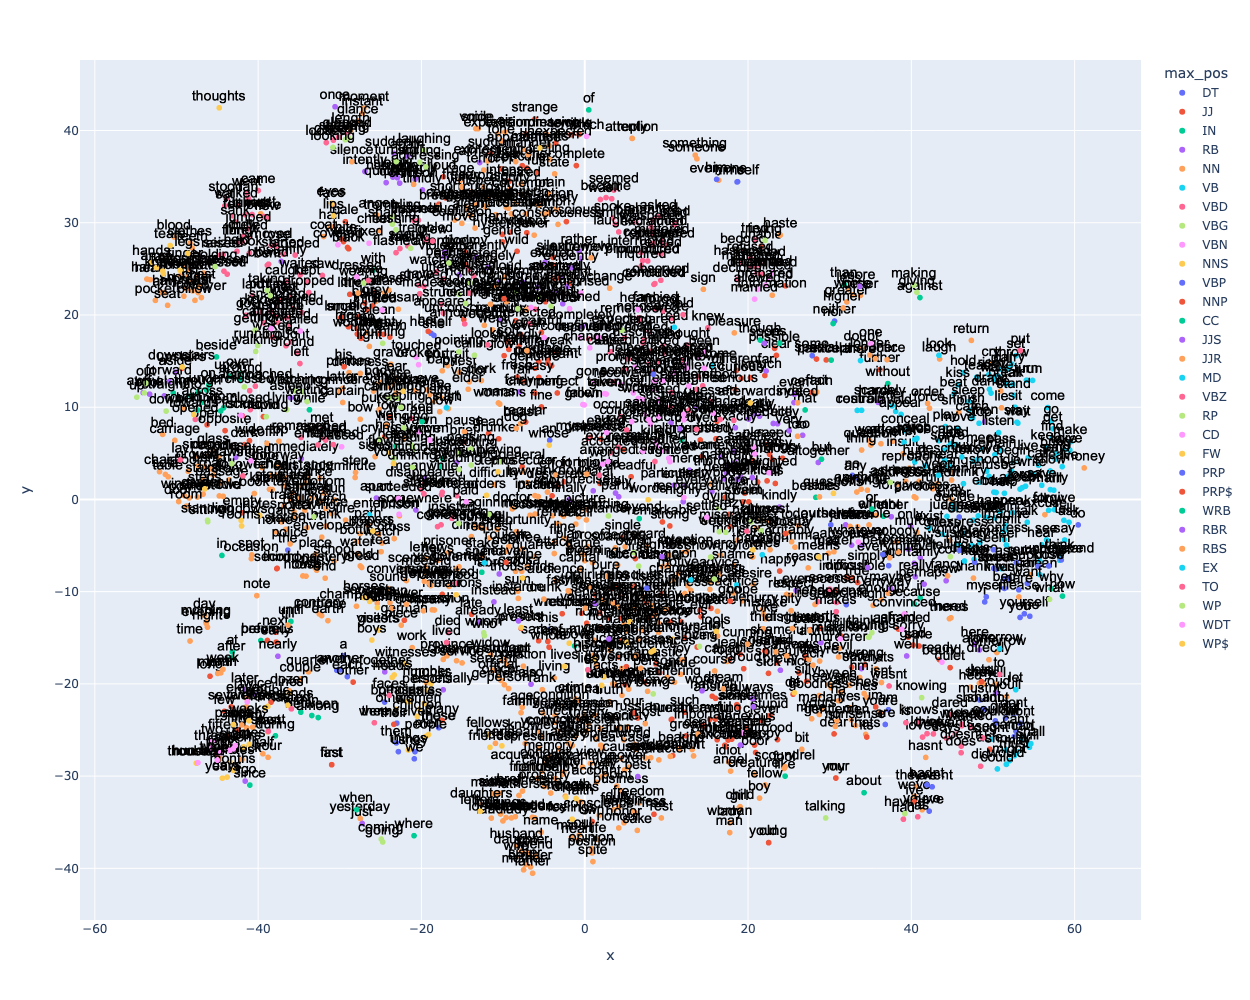

In [90]:
px.scatter(X.reset_index(), 'x', 'y', 
           text='term_str', 
           #size = 'n_log',
           color='max_pos', 
           hover_name='term_str',          
           height=1000, width=1200).update_traces(
                mode='markers+text', 
                textfont=dict(color='black', size=14, family='Arial'),
                textposition='top center')

**Need to add description**

### Riff 1

**Exploring topic weight for each translator**

In [91]:
TRANSLATORS = sorted(LIB.translator.value_counts().index.to_list())

In [92]:
TOPICS[TRANSLATORS] = THETA.join(LIB, on='book_id').groupby('translator')[TNAMES].mean().T

In [93]:
TOPICS

,top_terms,doc_weight_mean,C. J. Hogarth,Constance Garnett,Eva Martin
topic_id,,,,,
T00,love bye door silence surprise time voice,0.046327,0.044410,0.045456,0.049277
T01,man way time course people fact reason,0.046938,0.041987,0.048587,0.043050
T02,oh people men man hands heart world,0.051906,0.028322,0.055574,0.045739
T03,thats money place time question man scoundrel,0.050825,0.094565,0.050133,0.044232
T04,life years time woman man general house,0.054189,0.049186,0.048677,0.071438
T05,room time face hand hands eyes coat,0.049988,0.044350,0.051245,0.047395
T06,letter brother word hand answer didnt questions,0.053782,0.043051,0.055101,0.052011
T07,mind thought hour idea voice moment night,0.048754,0.064863,0.047350,0.049715
T08,man business time people ah money evidence,0.042710,0.044160,0.042361,0.043451


In [94]:
TOPICS[TRANSLATORS + ['top_terms']].sort_values('Constance Garnett', ascending=False)\
    .style.background_gradient(cmap=colors, axis=None)

,C. J. Hogarth,Constance Garnett,Eva Martin,top_terms
topic_id,,,,
T11,0.067447,0.066683,0.070593,yes eyes face smile man ha look
T16,0.066961,0.059702,0.055302,room door table chair note sofa sir
T02,0.028322,0.055574,0.045739,oh people men man hands heart world
T06,0.043051,0.055101,0.052011,letter brother word hand answer didnt questions
T19,0.036819,0.051879,0.054119,right door thing head fool dont air
T18,0.038007,0.051408,0.045999,day yesterday good suddenly youve days time
T05,0.044350,0.051245,0.047395,room time face hand hands eyes coat
T03,0.094565,0.050133,0.044232,thats money place time question man scoundrel
T10,0.076644,0.049675,0.048234,mother money roubles thousand sister away question


This plot shows topic weights organized by the translator who worked on the book. It is interesting to see that there are some differences, for example C. J. Hogarth translated *The Gambler,* a book centered around gambling as the title implies. The two topics that are most defined by money, topics 3 and 10, are by far the two most strongly associated with this work. In fact, they are the two most strongly associated with any translator's body of work. 

Another insight we can gain from this table is the Constance Garnett (who is responsible for four out of six works in this corpus) has a relatively even distribution of topics associated with her works. With the highest being 0.067 and the lowest being 0.042, she has the smallest range of any translator. 

Topic 12 jumps out as one that is weakly associated with Garnett, but strongly associated with Hogarth and Martin. This could suggest that Garnett's style of translation places less emphasisis on these kinds of ideas and more on other aspects of the story she is translating. Topic 12 includes words such as "house" "home" and "lady", which are all words associated with home (most of Dostoevsky's work centered around men, which is why "lady" could be associated more with the home in this corpus). Perhaps Garnett's style was more focused on the events outside the home and paid less attention to the mundane, but realistic, parts of life. It is also possible that she translated books that simply happened to not place emphasis on this topic, but the difference is interesting nonetheless.

### Riff 2

**Exploring Sentiment for each translator**

In [95]:
BOW_SENT3 = BOW_SENT.join(LIB['translator'], on = 'book_id')
EMO_TRANS = BOW_SENT3.groupby(['translator'])[emo_cols].mean()

In [96]:
EMO_TRANS # mean sentiment for each emotion for each translator

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
translator,,,,,,,,,
C. J. Hogarth,0.266919,0.285376,0.201136,0.292475,0.303360,0.303360,0.183625,0.340274,-0.048273
Constance Garnett,0.304128,0.247765,0.230275,0.350460,0.265546,0.325188,0.161115,0.316314,-0.143721
Eva Martin,0.277449,0.261923,0.208198,0.305596,0.294426,0.308165,0.171228,0.334301,-0.061544


<Axes: ylabel='translator'>

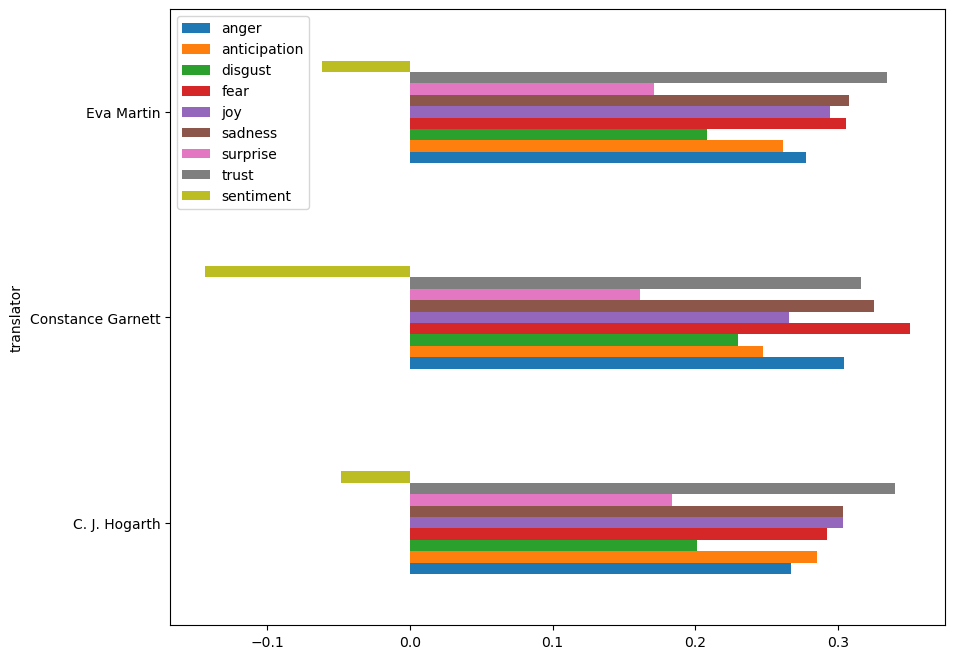

In [97]:
EMO_TRANS.plot.barh(figsize=(10,8))

Of note is the fact that Constance Garnett is responsible for the translation of four books in this corpus, and the other two translators are each responsible for one. Garnett's work tends to have a lower sentiment score, even though C. J. Hogarth translated *The Gambler,* which deals with themes of addiction and obsession, called "dark and compelling" by Random House Canada. The point is that translators may, and likely do, play an influential role in the reader's interpretation of the novel. The Sentiment Plot from earlier in the project shows that Dostoevsky stays relatively constant in terms of sentiment throughout this portion of his career, so some of the differences shown in this plot could very well be due to translators' choices.

### Riff 3

**Looking for changes in Dostoevsky's work over time**

In [98]:
def vis_pcs(M, a, b, label, hover_name='title', symbol=None, size=None):
    return px.scatter(M, f"PC{a}", f"PC{b}", color=label, hover_name=hover_name, 
                     symbol=symbol, size=size,
                     marginal_x='box', height=800)

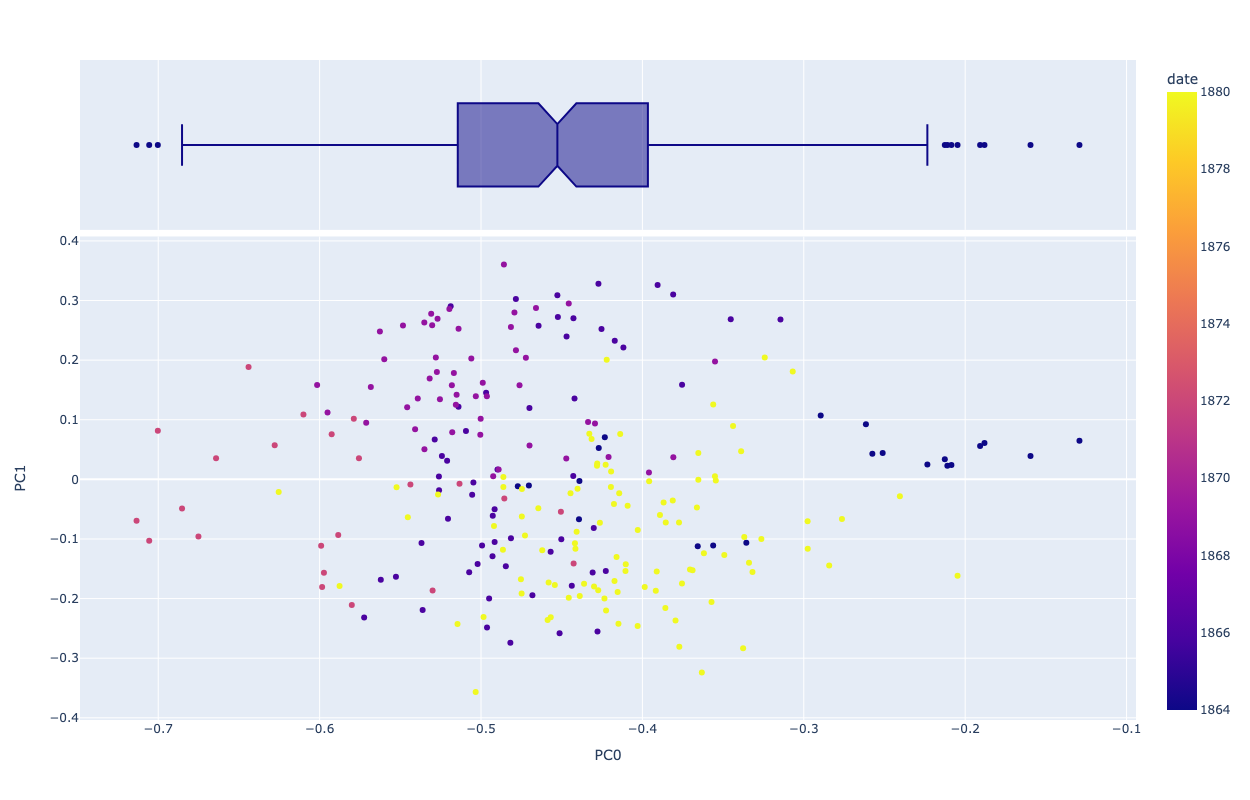

In [99]:
vis_pcs(DCM, 0, 1, label='date')

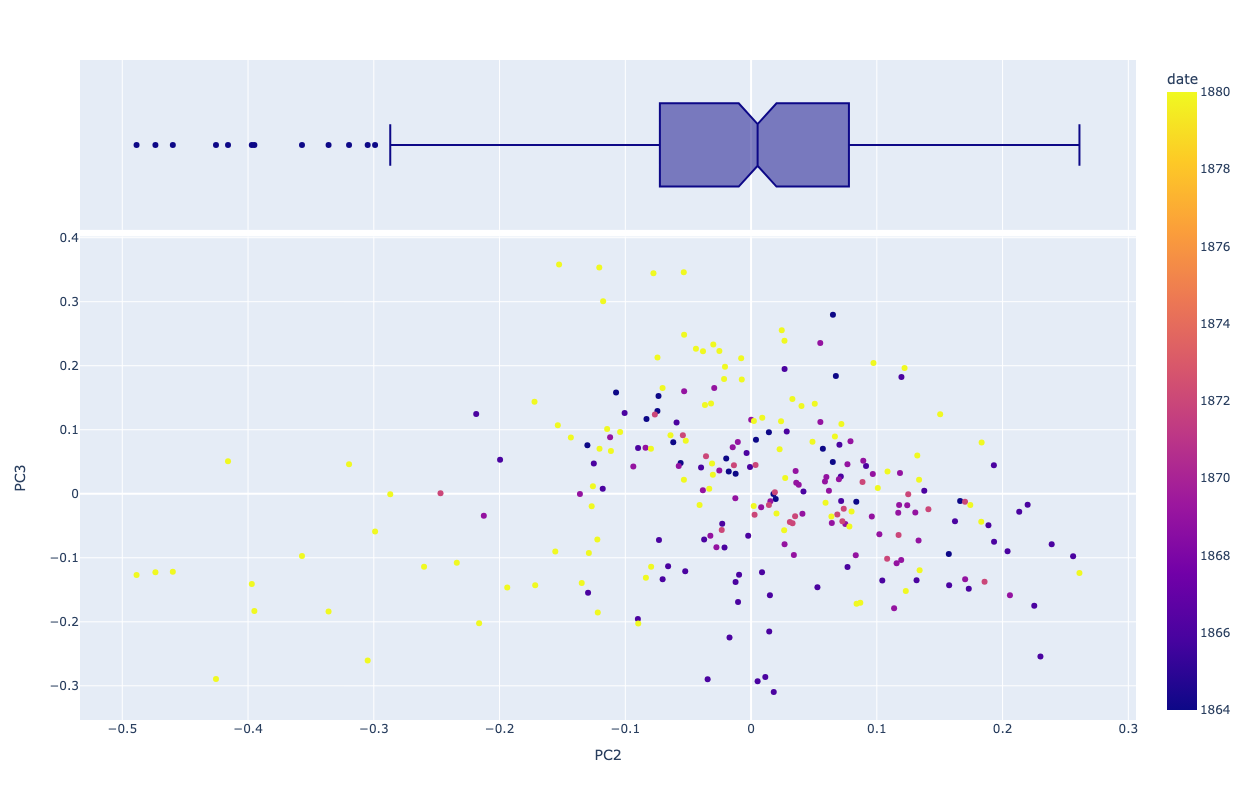

In [100]:
vis_pcs(DCM, 2, 3, label='date')

In [101]:
BOW_SENT4 = BOW_SENT.join(LIB['date'], on = 'book_id')
EMO_DATE = BOW_SENT4.groupby(['date'])[emo_cols].mean()

In [102]:
EMO_DATE # mean sentiment for each emotion for each translator

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
date,,,,,,,,,
1864,0.324225,0.229637,0.266947,0.343142,0.272202,0.332107,0.146611,0.306884,-0.172885
1866,0.292311,0.253497,0.225834,0.342590,0.258441,0.329231,0.164300,0.311560,-0.159882
1869,0.277449,0.261923,0.208198,0.305596,0.294426,0.308165,0.171228,0.334301,-0.061544
1872,0.303806,0.245144,0.218373,0.346325,0.266142,0.313780,0.163386,0.315486,-0.135564
1880,0.303983,0.253366,0.230384,0.350300,0.274727,0.324427,0.163060,0.324780,-0.119140


<Axes: ylabel='date'>

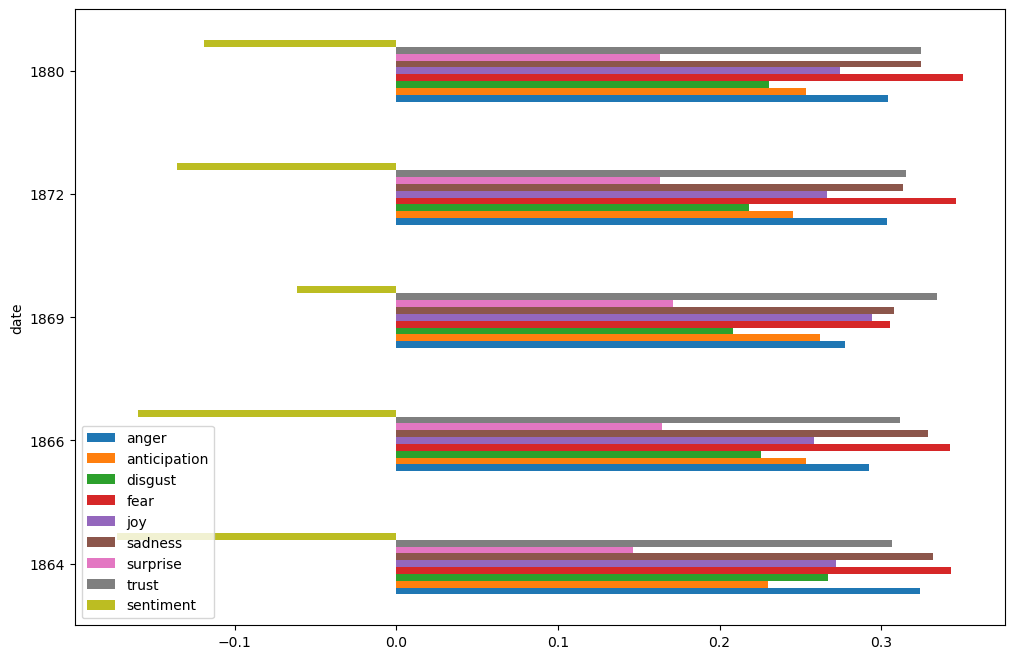

In [103]:
EMO_DATE.plot.barh(figsize=(12,8))

**Results show that, while many authors such as Jane Austen change over time, Dostoevsky stays relatively consistent throughout this portion of his career in terms of the components of his work and the sentiment behind it. This makes some sense because when writing these works, Dostoevsky is much older than Jane Austen was when she began writing so he is less likely to change in his real life. Also, much of his work is inspired by the suffering and hardship he endured when he was younger. These plots suggest that those themes remain relatively constant in his work since the major emotions in his books stay the same. However, the overall sentiment does become a little less negative over time.**

### Riff 4 (Extra- not focused on a LIB feature but just interesting)

In [104]:
# Bonus, sentiment by chapters for Crime and Punishment:

In [105]:
EMO_CHAPS = BOW_SENT.groupby(['book_id','chap_id'])[emo_cols].mean()
CaP_chaps_thin = EMO_CHAPS.stack().to_frame().reset_index().rename(columns={0:'value','level_2':'emo'}).query("book_id == {}".format(2554))

In [106]:
def plot_sentiments(df, emo='sentiment'):
    FIG = dict(figsize=(25, 5), legend=True, fontsize=14, rot=45)
    df[emo].plot(**FIG)

In [107]:
# plot_sentiments(PERSUASION_chaps, emo_cols)

/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



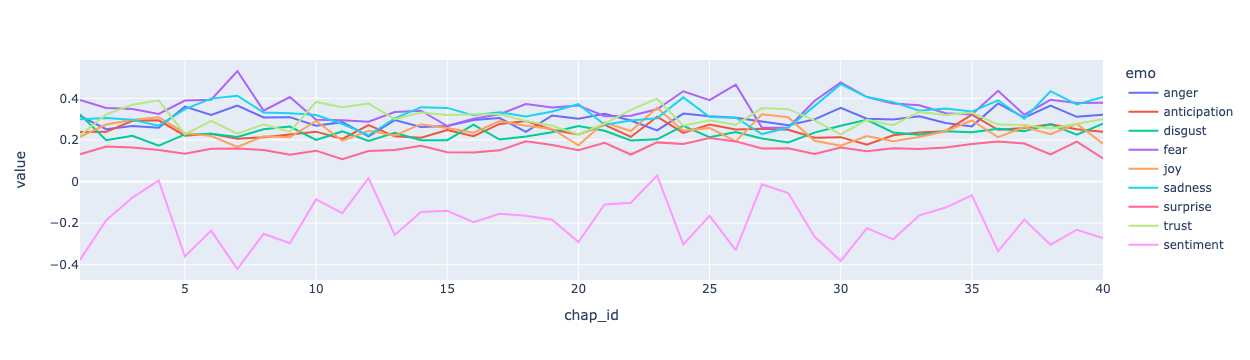

In [108]:
px.line(CaP_chaps_thin, x='chap_id', y='value', color='emo')

**Of note: chapter 7 is when he kills the two women and is almost caught right away. In chapter 26, he is almost caught again but saved by an unexpected distraction. In chapter 30, he confesses to the murders in front of a character who is a trusted friend, and we see fear and sadness spike while trust dips. This pattern supports the idea that the "punishment" in *Crime and Punishment* is the guilt, fear, and paranoia that he lives in after his crime. Also explains why fear is overall the most prevalent emotion in the novel.**

### Save Outputs

In [111]:
L2.to_csv(f"{output_dir}/{data_prefix}-TFIDF_L2_PCA.csv", index=True)
LOADINGS.to_csv(f"{output_dir}/{data_prefix}-PCA_Loadings.csv", index=True)
DCM.to_csv(f"{output_dir}/{data_prefix}-PCA_DCM.csv", index=True)
COMPINF.to_csv(f"{output_dir}/{data_prefix}-PCA_Components.csv", index=True)
TOPICS.to_csv(f"{output_dir}/{data_prefix}-LDA_TOPIC.csv", index=True)
THETA.to_csv(f"{output_dir}/{data_prefix}-LDA_THETA.csv", index=True)
PHI.to_csv(f"{output_dir}/{data_prefix}-LDA_PHI.csv", index=True)
VOCAB_SENT.to_csv(f"{output_dir}/{data_prefix}-VOCAB_SENT.csv", index=True)
BOW_SENT.to_csv(f"{output_dir}/{data_prefix}-BOW_SENT.csv", index=True)
DOC_SENT.to_csv(f"{output_dir}/{data_prefix}-DOC_SENT.csv", index=True)
VOCAB_W2V.to_csv(f"{output_dir}/{data_prefix}-VOCAB_W2V.csv", index=True)
DOCS.to_csv(f"{output_dir}/{data_prefix}-LDA_DOCS.csv", index=True)
SALEX.to_csv(f"{output_dir}/{data_prefix}-SALEX.csv", index=True)